# 03 — Feature Engineering

**BBL514E Pattern Recognition — Term Project (MVP)**

Bu notebook FAZ 1'de üretilen `data/processed/btc_aligned.csv` üzerinden tüm feature'ları üretir.
MVP scope'u gereği sadece **BTC** işlenir; ETH 2. iterasyonda eklenecek.

## adımlar
1. Aligned dataset yükle (BTC).
2. Teknik indikatörleri hesapla (trend / oscillator / volatility / volume).
3. Makro feature'ları hesapla (raw + ROC + rolling z-score + rolling mean + **derived spreads**).
4. Birleşik feature matrisi oluştur ve NaN warm-up satırlarını düşür.
5. **ADF durağanlık testi** (her feature için p-value).
6. Korelasyon ısı haritası (her stage feature havuzu için).
7. Örnek dağılım grafikleri.
8. Per-stage feature dosyalarını kaydet (`data/processed/btc_features_*.csv`).

## kararlar (MVP)
- **Sadece BTC**, ETH 2. iter.
- Selection bu notebook'ta henüz yapılmaz; label-bazlı (target-aware) MI/SHAP filtreleri training notebook'larında çalışacak.
- Tree-uyumlu kalması için scaling burada uygulanmaz; sadece MLP ve clustering kendi pipeline'ında fit-on-train scaler kullanır.
- Forward return ASLA feature olarak kullanılmaz — bu invariant `notebook 04`'te `verify_no_leakage` ile doğrulanır.

In [1]:
import sys
from pathlib import Path

# Notebook çalışma dizini = notebooks/, root = parent
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

from src.utils.config import cfg
from src.utils.helpers import save_csv
config = cfg()
print("Config loaded.")
print(f"Project root: {PROJECT_ROOT}")

Config loaded.
Project root: /Users/yurutkenozgun/Projects/hierarchical-trading-signal-classifier


## 1. Aligned dataset yükle (BTC)

FAZ 1 sonucu: 4111 satır, 17 sütun (5 OHLCV + 12 macro).

In [2]:
BTC_PATH = PROJECT_ROOT / "data" / "processed" / "btc_aligned.csv"
btc = pd.read_csv(BTC_PATH, index_col=0, parse_dates=True)

print(f"Shape: {btc.shape}")
print(f"Date range: {btc.index.min().date()} → {btc.index.max().date()}")
print(f"NaN: {btc.isna().sum().sum()}")
print(f"Columns ({len(btc.columns)}): {list(btc.columns)}")
btc.head(3)

Shape: (4111, 20)
Date range: 2014-09-17 → 2025-12-30
NaN: 0
Columns (20): ['Open', 'High', 'Low', 'Close', 'Volume', 'SP500', 'VIX', 'DXY', 'Gold', 'Silver', 'Oil_WTI', 'US10Y', 'US5Y', 'US3M', 'US30Y', 'US2Y', 'HY_Bond', 'IG_Bond', 'Treasury20Y', 'TIPS']


,Open,High,Low,Close,Volume,SP500,VIX,DXY,Gold,Silver,Oil_WTI,US10Y,US5Y,US3M,US30Y,US2Y,HY_Bond,IG_Bond,Treasury20Y,TIPS
Date,,,,,,,,,,,,,,,,,,,,
2014-09-17,465.8640,468.1740,452.4220,457.3340,21056800,"1,998.9800",12.7300,84.0700,"1,235.2000",18.6560,94.8800,2.5890,1.7740,0.0150,3.3540,109.8594,50.3614,78.9870,82.7971,84.4911
2014-09-18,456.8600,456.8600,413.1040,424.4400,34483200,"2,001.5699",12.6500,84.7000,"1,234.4000",18.6630,94.4200,2.6000,1.8040,0.0130,3.3640,109.8203,50.5244,78.7721,82.5848,83.9216
2014-09-19,424.1030,427.8350,384.5320,394.7960,37919700,"2,011.3600",12.0300,84.3200,"1,225.7000",18.4520,93.0700,2.6290,1.8410,0.0100,3.3590,109.8047,50.5407,78.9131,82.8484,83.7043


## 2. Teknik indikatörleri hesapla

`src/features/technical_indicators.py` 4 kategori üretir:
- **Trend** (Stage 1 adayları): SMA/EMA/ADX/PSAR + crossover + price-distance
- **Oscillator** (Stage 3 adayları): RSI/Stoch/MACD/Williams%R/CCI/ROC
- **Volatility**: Bollinger/ATR/historical-vol
- **Volume**: OBV/Volume_SMA/Volume_ROC

In [3]:
from src.features.technical_indicators import compute_all_technical_indicators

tech = compute_all_technical_indicators(btc[["Open", "High", "Low", "Close", "Volume"]])

for name, df in tech.items():
    print(f"{name:12s} → {df.shape[1]} cols, {df.notna().any(axis=1).sum()} valid rows")
    print(f"             columns: {list(df.columns)}")
print()
print("Sample (last 3 rows of trend):")
tech["trend"].tail(3)

2026-05-07 19:17:26 | src.features.technical_indicators | INFO | Computing all technical indicators for 4111 rows


2026-05-07 19:17:26 | src.features.technical_indicators | INFO | Computed 16 trend indicators


2026-05-07 19:17:26 | src.features.technical_indicators | INFO | Computed 9 oscillator indicators


2026-05-07 19:17:26 | src.features.technical_indicators | INFO | Computed 6 volatility indicators


2026-05-07 19:17:26 | src.features.technical_indicators | INFO | Computed 3 volume indicators


trend        → 16 cols, 4111 valid rows
             columns: ['SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'ADX_14', 'DI_plus_14', 'DI_minus_14', 'PSAR', 'PSAR_up', 'PSAR_down', 'SMA20_SMA50_cross', 'SMA50_SMA200_cross', 'price_dist_SMA20_pct', 'price_dist_SMA50_pct', 'price_dist_SMA200_pct']
oscillator   → 9 cols, 4101 valid rows
             columns: ['RSI_14', 'Stoch_K_14', 'Stoch_D_3', 'MACD_line', 'MACD_signal', 'MACD_histogram', 'Williams_R_14', 'CCI_20', 'ROC_10']
volatility   → 6 cols, 4111 valid rows
             columns: ['BB_upper', 'BB_lower', 'BB_bandwidth', 'BB_pct_b', 'ATR_14', 'hist_volatility_20']
volume       → 3 cols, 4111 valid rows
             columns: ['OBV', 'Volume_SMA_20', 'Volume_ROC']

Sample (last 3 rows of trend):


,SMA_20,SMA_50,SMA_200,EMA_12,EMA_26,ADX_14,DI_plus_14,DI_minus_14,PSAR,PSAR_up,PSAR_down,SMA20_SMA50_cross,SMA50_SMA200_cross,price_dist_SMA20_pct,price_dist_SMA50_pct,price_dist_SMA200_pct
Date,,,,,,,,,,,,,,,,
2025-12-28,"88,529.8801","90,842.1881","107,298.5132","87,901.0290","89,042.9281",19.3256,16.7129,18.2456,"90,830.9992",0.0000,0.0000,"-2,312.3080","-16,456.3251",-0.7840,-3.3094,-18.1388
2025-12-29,"88,252.2016","90,490.5581","107,182.7334","87,783.6615","88,901.8327",18.8359,21.2308,16.5230,"90,575.2117",0.0000,0.0000,"-2,238.3566","-16,692.1753",-1.2624,-3.7047,-18.7013
2025-12-30,"88,072.6609","90,139.2289","107,073.5979","87,883.1186","88,866.8920",18.3812,19.7910,15.4025,"90,329.6557",0.0000,0.0000,"-2,066.5680","-16,934.3690",0.4059,-1.8961,-17.4118


## 3. Makro feature'ları

`src/features/macro_features.py`:
- Raw makro değerleri
- Her makro için ROC ([5, 20, 50] gün) + rolling z-score ([20, 50, 100]) + rolling mean
- **Derived spreads** (yeni MVP eklemesi):
  - `Yield_Curve_10Y_2Y` = US10Y − US2Y
  - `Credit_Spread_log` = log(HY_Bond) − log(IG_Bond)
  - `Gold_Silver_Ratio` = Gold / Silver
  - `SP500_VIX_ratio` = SP500 / VIX
- Derived spread'ler için ayrıca rolling z-score'lar

In [4]:
from src.features.macro_features import compute_macro_features, compute_derived_spreads

# Sadece spreads'i ön izleme
spreads = compute_derived_spreads(btc)
print(f"Derived spreads ({spreads.shape[1]} cols): {list(spreads.columns)}")
spreads.tail(3)

2026-05-07 19:17:26 | src.features.macro_features | INFO | Computed 4 derived spread features


Derived spreads (4 cols): ['macro_Yield_Curve_10Y_2Y', 'macro_Credit_Spread_log', 'macro_Gold_Silver_Ratio', 'macro_SP500_VIX_ratio']


,macro_Yield_Curve_10Y_2Y,macro_Credit_Spread_log,macro_Gold_Silver_Ratio,macro_SP500_VIX_ratio
Date,,,,
2025-12-28,-100.1492,-0.3195,59.2148,509.5544
2025-12-29,-100.1492,-0.3195,59.2148,509.5544
2025-12-30,-100.2082,-0.3205,61.9145,486.3197


In [5]:
macro_feat = compute_macro_features(btc)
print(f"Total macro features: {macro_feat.shape[1]}")
print(f"Valid rows (all features non-NaN): {macro_feat.dropna().shape[0]}")
print()
print("Macro feature groups:")
groups = {}
for col in macro_feat.columns:
    if "_zscore_" in col: groups.setdefault("zscore", []).append(col)
    elif "_roc_" in col: groups.setdefault("roc", []).append(col)
    elif "_sma_" in col: groups.setdefault("sma", []).append(col)
    else: groups.setdefault("raw_or_derived", []).append(col)
for k, v in groups.items():
    print(f"  {k:20s}: {len(v):3d} cols")

2026-05-07 19:17:26 | src.features.macro_features | INFO | Computing macro features for columns: ['SP500', 'VIX', 'DXY', 'Gold', 'Silver', 'Oil_WTI', 'US10Y', 'US5Y', 'US3M', 'US30Y', 'US2Y', 'HY_Bond', 'IG_Bond', 'Treasury20Y', 'TIPS']


2026-05-07 19:17:26 | src.features.macro_features | INFO | Computed 4 derived spread features


2026-05-07 19:17:26 | src.features.macro_features | INFO | Computed 166 macro features total


Total macro features: 166
Valid rows (all features non-NaN): 4012

Macro feature groups:
  raw_or_derived      :  19 cols
  roc                 :  45 cols
  zscore              :  57 cols
  sma                 :  45 cols


## 4. Birleşik feature matrisi

Tüm feature'lar tek DataFrame'de toplanır. Warm-up nedeniyle ilk ~200 satırda bazı SMA/zscore feature'ları NaN olabilir; bu satırlar Stage 1/3 eğitiminde otomatik düşürülür (`fillna(median)` veya target ile align).

In [6]:
all_feats = pd.concat(
    [tech["trend"], tech["oscillator"], tech["volatility"], tech["volume"], macro_feat],
    axis=1,
)
print(f"Combined feature matrix: {all_feats.shape}")
print(f"  Trend candidates    : {tech['trend'].shape[1]}")
print(f"  Oscillator candidates: {tech['oscillator'].shape[1]}")
print(f"  Volatility           : {tech['volatility'].shape[1]}")
print(f"  Volume               : {tech['volume'].shape[1]}")
print(f"  Macro                : {macro_feat.shape[1]}")
print()
warmup_threshold = 200
valid_after_warmup = all_feats.iloc[warmup_threshold:].dropna()
print(f"After {warmup_threshold}-row warm-up + dropna: {valid_after_warmup.shape}")

Combined feature matrix: (4111, 200)
  Trend candidates    : 16
  Oscillator candidates: 9
  Volatility           : 6
  Volume               : 3
  Macro                : 166

After 200-row warm-up + dropna: (3911, 200)


## 5. ADF durağanlık testi

Her feature için Augmented Dickey-Fuller. `p < 0.05` → durağan (level kullanılabilir). `p ≥ 0.05` → durağan değil (raporda not edilecek; tree modeller buna karşı dayanıklı ama LDA/MLP için dikkat).

Durağan olmayanlar için ROC/zscore versiyonları zaten mevcut, bu yeterli.

In [7]:
def adf_test(series: pd.Series) -> dict:
    s = series.dropna()
    if len(s) < 50:
        return {"adf_stat": np.nan, "p_value": np.nan, "stationary": None}
    try:
        stat, p, *_ = adfuller(s, autolag="AIC", maxlag=20)
        return {"adf_stat": stat, "p_value": p, "stationary": p < 0.05}
    except Exception:
        return {"adf_stat": np.nan, "p_value": np.nan, "stationary": None}

adf_rows = []
for col in all_feats.columns:
    res = adf_test(all_feats[col])
    res["feature"] = col
    adf_rows.append(res)

adf_df = pd.DataFrame(adf_rows).set_index("feature")
stationary_count = adf_df["stationary"].sum()
total_tested = adf_df["stationary"].notna().sum()
print(f"ADF results: {stationary_count}/{total_tested} stationary (p < 0.05)")
print()
print("--- Top 10 most non-stationary features (highest p-value) ---")
print(adf_df.dropna(subset=["p_value"]).sort_values("p_value", ascending=False).head(10))
print()
print("--- Sample stationary features (lowest p-value) ---")
print(adf_df.dropna(subset=["p_value"]).sort_values("p_value").head(10))

ADF results: 136/200 stationary (p < 0.05)

--- Top 10 most non-stationary features (highest p-value) ---
                      adf_stat  p_value  stationary
feature                                            
macro_Silver            4.6108   1.0000       False
macro_Gold_sma_20       8.0801   1.0000       False
macro_Gold_sma_50       4.0395   1.0000       False
macro_Gold_sma_100      3.5579   1.0000       False
macro_Silver_sma_20     6.9104   1.0000       False
macro_Silver_sma_50     3.7576   1.0000       False
macro_Gold              4.6697   1.0000       False
macro_Silver_sma_100    2.6138   0.9991       False
macro_SP500_sma_20      1.9860   0.9987       False
macro_SP500_sma_50      1.0777   0.9950       False

--- Sample stationary features (lowest p-value) ---
                                    adf_stat  p_value  stationary
feature                                                          
PSAR_up                             -19.7086   0.0000        True
PSAR_down          

## 6. Korelasyon analizi

Her stage'in feature havuzu için ayrı korelasyon ısı haritası. Çok yüksek korelasyon (>0.95) `feature_selector.remove_highly_correlated` ile training'de filtrelenecek.

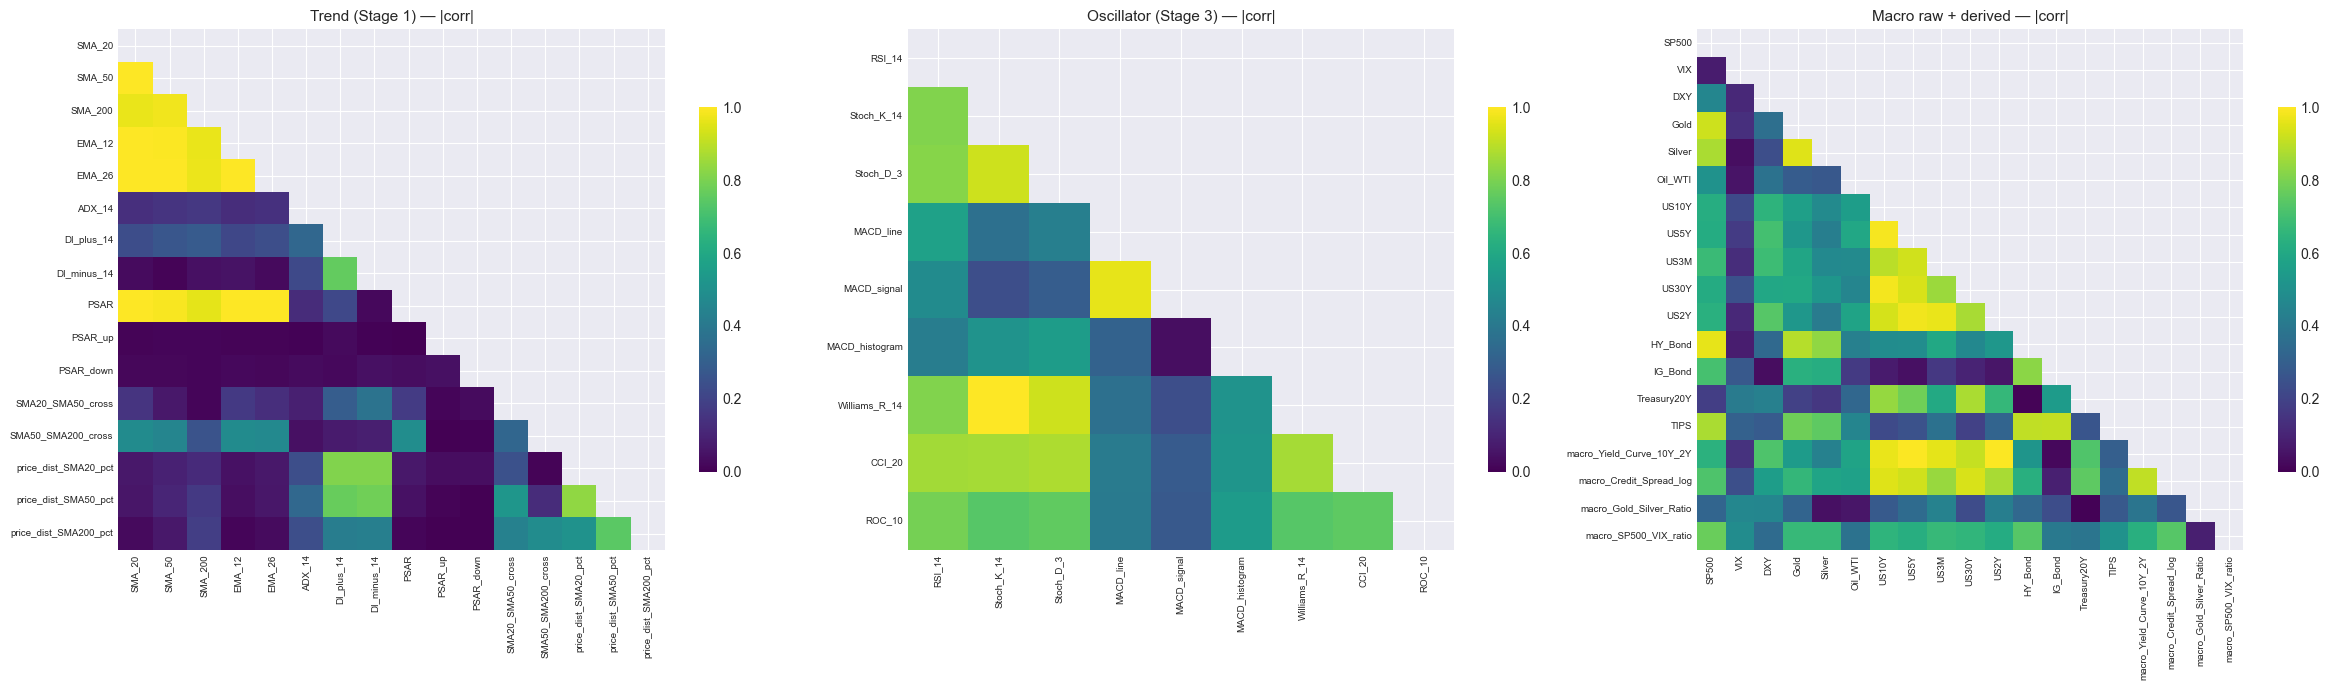

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (name, df) in zip(axes, [
    ("Trend (Stage 1)", tech["trend"]),
    ("Oscillator (Stage 3)", tech["oscillator"]),
    ("Macro raw + derived", btc[[c for c in btc.columns if c not in ["Open","High","Low","Close","Volume"]]].join(spreads)),
]):
    corr = df.corr().abs()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=False, cmap="viridis", vmin=0, vmax=1,
                ax=ax, cbar_kws={"shrink": 0.7})
    ax.set_title(f"{name} — |corr|", fontsize=11)
    ax.tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "feature_correlations.png", dpi=120, bbox_inches="tight")
plt.show()

In [9]:
# Yüksek korelasyonlu (|r| > 0.95) feature çiftleri — her stage için sayı
def count_high_corr_pairs(df: pd.DataFrame, threshold: float = 0.95) -> int:
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    return int((upper > threshold).sum().sum())

for name, df in [("trend", tech["trend"]), ("oscillator", tech["oscillator"]),
                  ("volatility", tech["volatility"]), ("volume", tech["volume"]),
                  ("macro", macro_feat)]:
    n = count_high_corr_pairs(df)
    print(f"{name:12s}: {df.shape[1]:3d} features, {n:3d} pairs with |r| > 0.95")

trend       :  16 features,  15 pairs with |r| > 0.95
oscillator  :   9 features,   2 pairs with |r| > 0.95
volatility  :   6 features,   1 pairs with |r| > 0.95
volume      :   3 features,   0 pairs with |r| > 0.95
macro       : 166 features, 196 pairs with |r| > 0.95


## 7. Dağılım ve zaman serisi görselleri (örnek feature'lar)

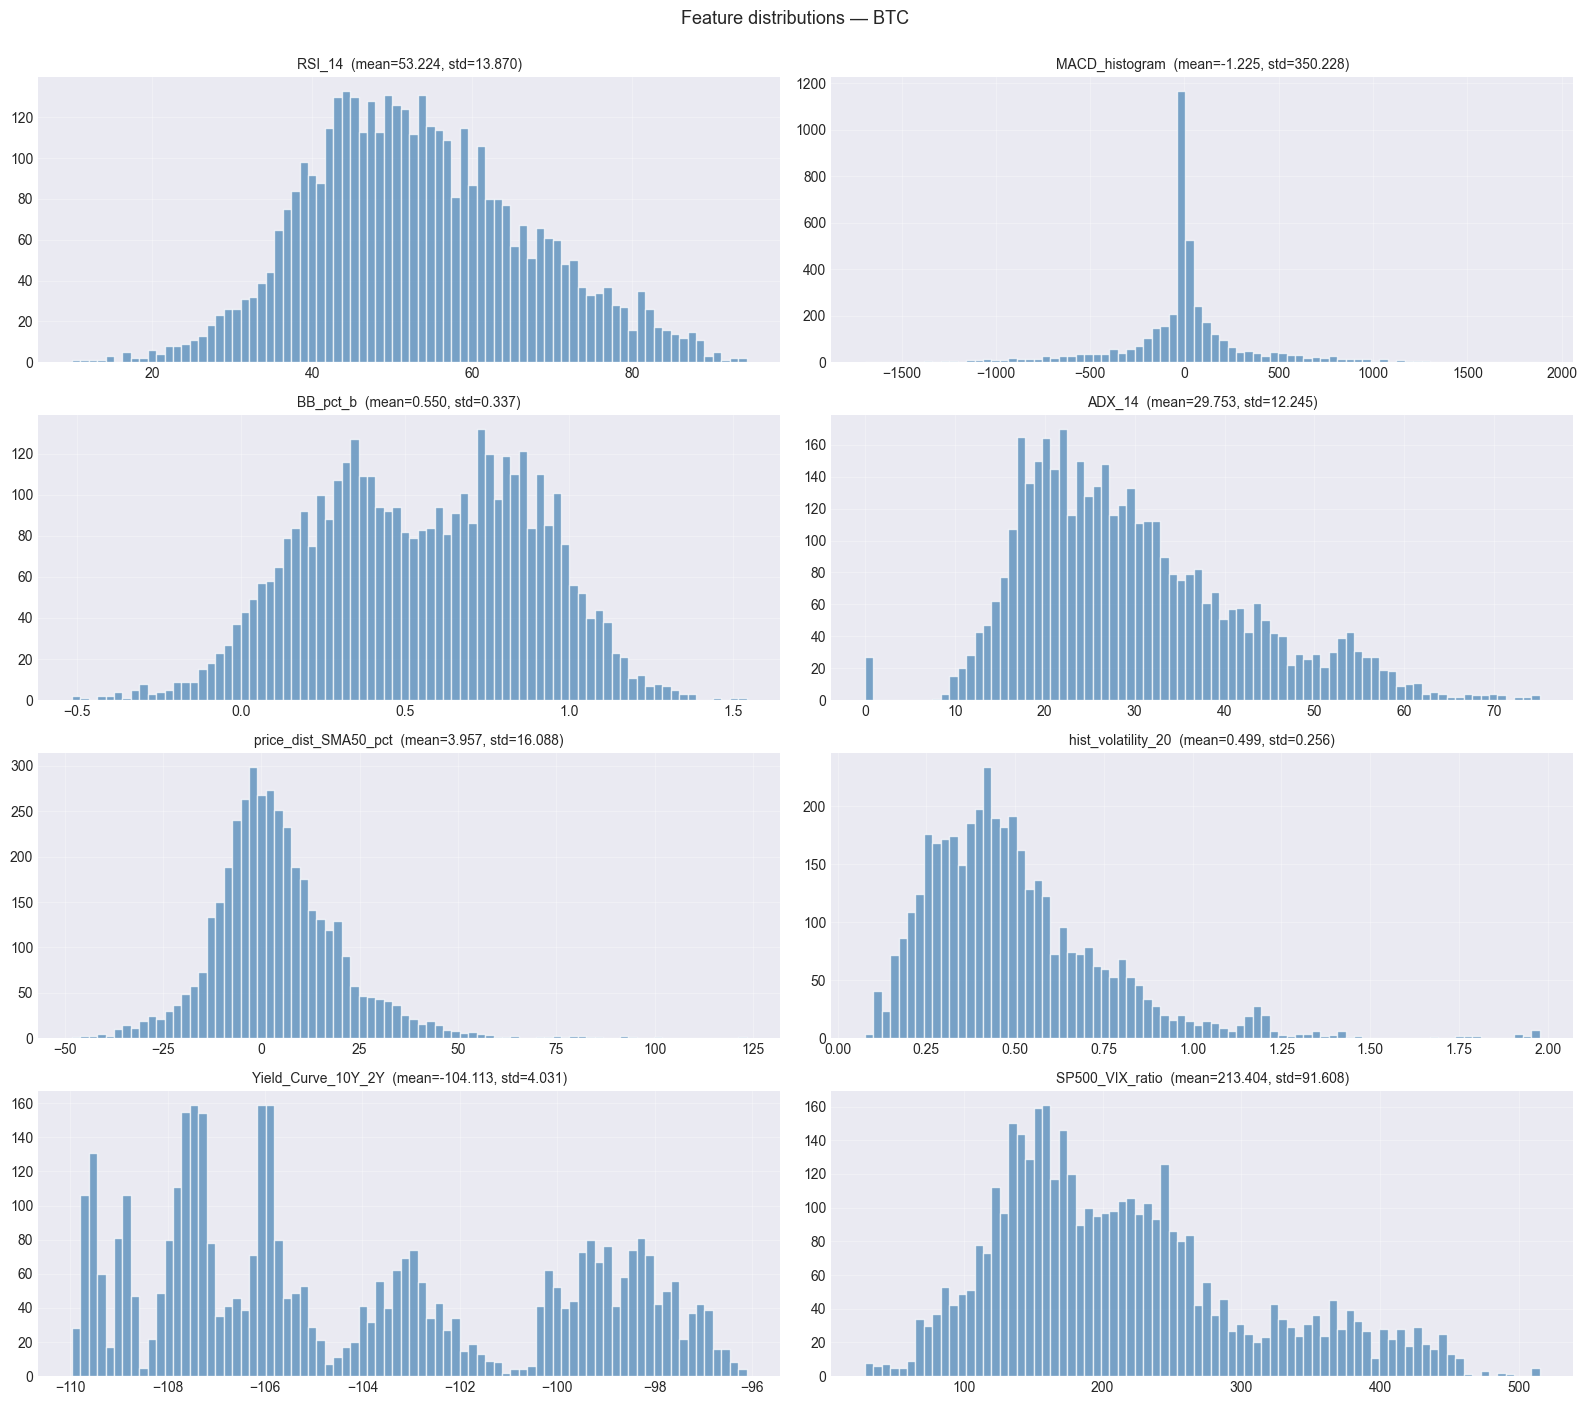

In [10]:
sample_features = {
    "RSI_14": tech["oscillator"]["RSI_14"],
    "MACD_histogram": tech["oscillator"]["MACD_histogram"],
    "BB_pct_b": tech["volatility"]["BB_pct_b"],
    "ADX_14": tech["trend"]["ADX_14"],
    "price_dist_SMA50_pct": tech["trend"]["price_dist_SMA50_pct"],
    "hist_volatility_20": tech["volatility"]["hist_volatility_20"],
    "Yield_Curve_10Y_2Y": spreads["macro_Yield_Curve_10Y_2Y"] if "macro_Yield_Curve_10Y_2Y" in spreads.columns else None,
    "SP500_VIX_ratio": spreads["macro_SP500_VIX_ratio"] if "macro_SP500_VIX_ratio" in spreads.columns else None,
}

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
for (name, ser), ax in zip([(k, v) for k, v in sample_features.items() if v is not None], axes.flatten()):
    ax.hist(ser.dropna(), bins=80, color="steelblue", alpha=0.7, edgecolor="white")
    ax.set_title(f"{name}  (mean={ser.mean():.3f}, std={ser.std():.3f})", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Feature distributions — BTC", fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Per-stage feature dosyalarını kaydet

MVP konvansiyonu:
- `btc_features_stage1.csv` — trend feature havuzu (Stage 1 eğitimi için)
- `btc_features_stage3.csv` — oscillator + volatility + volume + (volume için MVP'de yer almayabilir) (Stage 3 eğitimi için)
- `btc_features_macro.csv` — tüm makro feature'lar (Stage 2 clustering input)
- `btc_features_all.csv` — birleşik (flat baseline ablation 2. iter)

In [11]:
out_dir = PROJECT_ROOT / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)

# Stage 1: trend candidates only
stage1_feats = tech["trend"]
save_csv(stage1_feats, out_dir / "btc_features_stage1.csv")

# Stage 3: oscillator + volatility + volume
stage3_feats = pd.concat([tech["oscillator"], tech["volatility"], tech["volume"]], axis=1)
save_csv(stage3_feats, out_dir / "btc_features_stage3.csv")

# Macro features (Stage 2 clustering)
save_csv(macro_feat, out_dir / "btc_features_macro.csv")

# All features (flat baseline ablation — 2. iter)
save_csv(all_feats, out_dir / "btc_features_all.csv")

# ADF results for the report
save_csv(adf_df, out_dir / "btc_adf_results.csv")

print("Saved feature files:")
for p in sorted(out_dir.glob("btc_features_*.csv")):
    print(f"  {p.name:30s} {p.stat().st_size / 1024:8.1f} KB")
print(f"  btc_adf_results.csv             {(out_dir / 'btc_adf_results.csv').stat().st_size / 1024:8.1f} KB")

Saved feature files:
  btc_features_all.csv            15114.6 KB
  btc_features_macro.csv          12772.9 KB
  btc_features_stage1.csv          1086.8 KB
  btc_features_stage3.csv          1343.3 KB
  btc_adf_results.csv                 12.6 KB


## Checkpoint — Kullanıcı İnceleme Noktası #1

**Notebook'u `restart & run all` ile çalıştır ve aşağıdakileri kontrol et:**

### Beklenen Çıktılar
1. Combined feature matrix shape ~ (4111, ~170+) (warm-up sonrası ~3900 valid satır).
2. Derived spreads 4 adet görünmeli: Yield Curve, Credit Spread (log), Gold/Silver, SP500/VIX.
3. ADF: zscore'lar ve ROC'lar durağan, raw level'lar (US10Y, Gold, vs.) genelde durağan değil — bu beklenen.
4. Yüksek korelasyon çifti sayıları makul (trend ve oscillator'da SMA periyotları arası >0.95 normal).
5. Distribution plot'lar şekilsel olarak makul (RSI 0-100, MACD merkezi 0, BB %b ~0-1).

### Sorular
- Derived spread seçimim (Yield Curve, Credit, Gold/Silver, SP500/VIX) yeterli mi?
- Volume feature'ları Stage 3'e dahil ettim, bu kabul mu yoksa volume'ü trend tarafına mı koyayım?
- ADF non-stationary feature'ları raporda nasıl ele alalım? (öneri: tree modeller robust, LDA/MLP için zscore versiyonlarını öncelikle seçeriz)

### Sonraki Adım
Onaylarsan → **FAZ 3: Label Generation** (`04_label_generation.ipynb`):
- Stage 1 (Trend) etiketleri: SMA crossover + 3-day persistence
- Stage 2 (Macro Regime): GMM soft posterior OOF (yeni MVP yaklaşımı)
- Stage 3 (Signal): forward-return ile Buy/Sell/Hold + leakage assertion